In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.decomposition import PCA

buy vs sell anomalies

In [ ]:
# gather data

df = pd.read_csv("carbon_trading_dataset.csv")
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%y')
df = df.sort_values(by='Date')
df['sorted_index'] = range(len(df))

relevant_cols = [
    "Energy_Demand_MWh", "Emission_Produced_tCO2", "Emission_Allowance_tCO2",
    "Carbon_Price_USD_per_t", "Credits_Traded_tCO2",
    "Compliance_Cost_USD", "Carbon_Cost_Savings_USD"
]
n_timesteps = len(df)
n_features = len(relevant_cols)

# all anomalies
anoms = [46, 86, 91, 173, 286, 559, 586, 636, 704, 928, 987, 1269, 1356, 1523, 1675, 1831, 1849, 1948, 1985, 2166, 2183, 2186, 2207, 2311, 2547, 2690, 2873, 2961, 2976,
         3048, 3247, 3634, 3712, 4174, 4175, 4215, 4355, 4371, 4385, 4466, 4528, 4697, 4772, 4898]

buy = []
sell = []

# create proper subsets
for anom in anoms:
  value = df.iloc[anom][df.columns.get_loc("Transaction_Type")]
  if (value == 'Buy'):
      buy.append(anom)
  elif (value == 'Sell'):
      sell.append(anom)
  else:
    print('error?')

print('buy')
print(buy)
print()
print('sell')
print(sell)

df.iloc[sell]

buy
[46, 286, 987, 1523, 1675, 1831, 1849, 1985, 2166, 2183, 2207, 2547, 2690, 2976, 3048, 3634, 4174, 4175, 4355, 4466, 4528, 4898]

sell
[86, 91, 173, 559, 586, 636, 704, 928, 1269, 1356, 1948, 2186, 2311, 2873, 2961, 3247, 3712, 4215, 4371, 4385, 4697, 4772]


/tmp/ipython-input-3614542896.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  value = df.iloc[anom][df.columns.get_loc("Transaction_Type")]


,Company_ID,Industry_Type,Date,Energy_Demand_MWh,Fuel_Type,Emission_Produced_tCO2,Emission_Allowance_tCO2,Carbon_Price_USD_per_t,Transaction_Type,Credits_Traded_tCO2,Verification_Status,Compliance_Cost_USD,Optimization_Scenario,Carbon_Cost_Savings_USD,Target_Trade_Action,sorted_index
589,C020,Cement,2024-01-11,532.44,Coal,233.34,172.34,29.83,Sell,74,Verified,16219.74,Low_Demand,2465.73,0,86
3656,C094,Cement,2024-01-12,620.92,Natural Gas,220.21,50.21,34.19,Sell,172,Verified,19362.53,Price_Surge,1013.87,0,91
640,C048,Manufacturing,2024-01-27,691.60,Coal,331.57,139.57,24.33,Sell,29,Disputed,12018.67,High_Demand,903.52,0,173
4401,C061,Cement,2024-03-21,671.34,Renewable,244.65,64.65,33.39,Sell,186,Verified,8400.31,Low_Demand,1041.17,0,559
3595,C067,Steel,2024-03-24,556.14,Renewable,172.56,151.56,21.56,Sell,35,Verified,12231.83,Price_Surge,754.81,0,586
1964,C054,Steel,2024-03-30,753.44,Mixed Fuel,255.86,96.86,20.64,Sell,72,Verified,12037.34,High_Demand,1519.66,0,636
3364,C036,Steel,2024-04-10,646.07,Coal,253.28,92.28,34.71,Sell,62,Disputed,17380.83,Low_Demand,2451.53,0,704
4862,C074,Manufacturing,2024-05-11,566.42,Renewable,248.24,97.24,34.59,Sell,43,Verified,5030.46,Price_Surge,1905.55,0,928
3866,C030,Energy,2024-06-29,575.30,Natural Gas,175.24,363.24,24.12,Sell,198,Disputed,6230.47,Price_Surge,1598.80,0,1269
1916,C055,Manufacturing,2024-07-12,516.33,Natural Gas,217.03,82.03,20.98,Sell,41,Verified,6425.38,Low_Demand,947.32,0,1356


anomaly analysis starts HERE

In [ ]:
cols_to_scale = [
    "Energy_Demand_MWh", "Emission_Produced_tCO2", "Emission_Allowance_tCO2",
    "Carbon_Price_USD_per_t", "Credits_Traded_tCO2",
    "Compliance_Cost_USD", "Carbon_Cost_Savings_USD"
]

df_temp = df.copy()

for col in cols_to_scale:
    df_temp[col] = np.log1p(df_temp[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_temp[cols_to_scale])


pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

pc_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pc_names, index=df.index)

df_remaining = df.drop(columns=cols_to_scale)
df_final = pd.concat([df_remaining, df_pca], axis=1)

# importants
df_buy_anomalies = df_final.iloc[buy]
df_buy_anomalies_scientific_data = df_temp[cols_to_scale].iloc[buy]

df_sell_anomalies = df_final.iloc[sell]
df_sell_anomalies_scientific_data = df_temp[cols_to_scale].iloc[sell]


df_all_anomalies = pd.concat([df_buy_anomalies, df_sell_anomalies])
df_all_anomalies_scientific_data = pd.concat([df_buy_anomalies_scientific_data, df_sell_anomalies_scientific_data])

df_all_anomalies_pca = df_all_anomalies[['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'sorted_index']]
df_non_anomalies_pca = df_pca[~df_pca.index.isin(df_all_anomalies_pca.index)]
df_non_anomalies_pca['sorted_index'] = df.loc[df_non_anomalies_pca.index, 'sorted_index']

# df_non_anomalies_pca
# df_all_anomalies_pca

# yes

/tmp/ipython-input-849170455.py:38: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



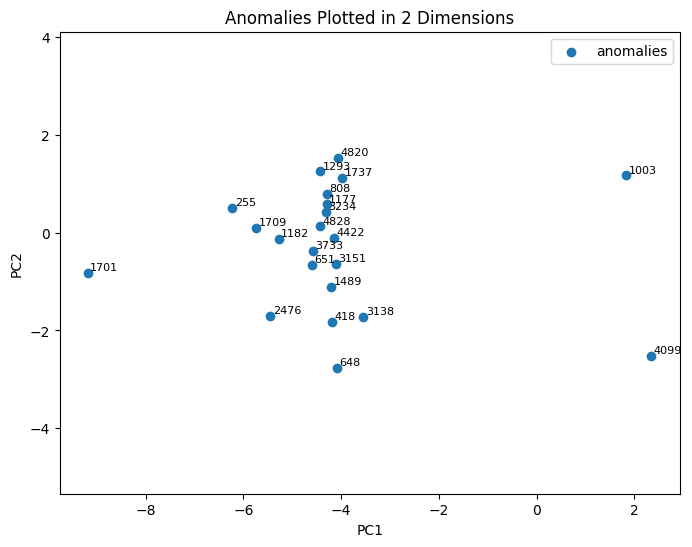

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df_buy_anomalies["PC1"], df_buy_anomalies["PC2"], label='anomalies')
for i, idx in enumerate(df_buy_anomalies.index):
    plt.text(df_buy_anomalies["PC1"].iloc[i] + 0.05, df_buy_anomalies["PC2"].iloc[i] + 0.05, str(idx),
             fontsize=8, color='black')
plt.axis('equal')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Anomalies Plotted in 2 Dimensions")
plt.legend()
plt.show()

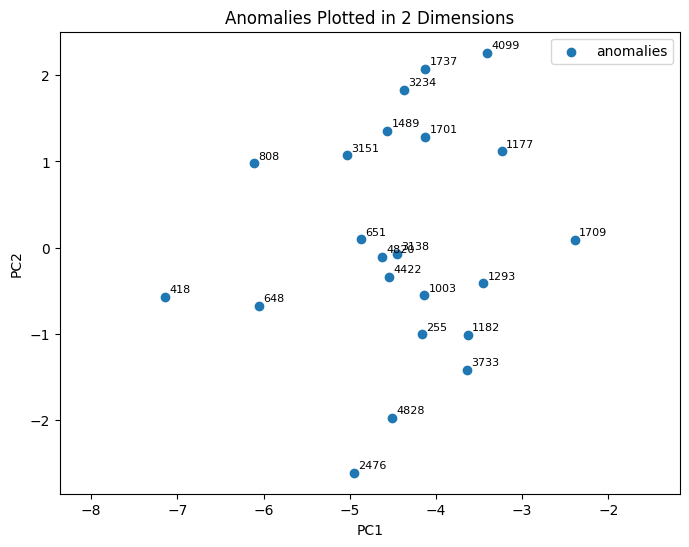

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df_sell_anomalies["PC1"], df_sell_anomalies["PC2"], label='anomalies')
for i, idx in enumerate(df_buy_anomalies.index):
    plt.text(df_sell_anomalies["PC1"].iloc[i] + 0.05, df_sell_anomalies["PC2"].iloc[i] + 0.05, str(idx),
             fontsize=8, color='black')
plt.axis('equal')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Anomalies Plotted in 2 Dimensions")
plt.legend()
plt.show()

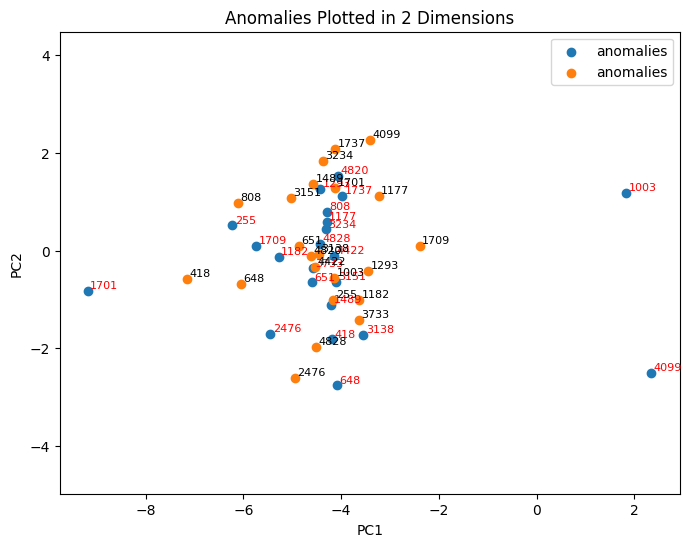

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df_buy_anomalies["PC1"], df_buy_anomalies["PC2"], label='anomalies')
plt.scatter(df_sell_anomalies["PC1"], df_sell_anomalies["PC2"], label='anomalies')

for i, idx in enumerate(df_buy_anomalies.index):
    plt.text(df_buy_anomalies["PC1"].iloc[i] + 0.05, df_buy_anomalies["PC2"].iloc[i] + 0.05, str(idx),
             fontsize=8, color='red')
for i, idx in enumerate(df_buy_anomalies.index):
    plt.text(df_sell_anomalies["PC1"].iloc[i] + 0.05, df_sell_anomalies["PC2"].iloc[i] + 0.05, str(idx),
             fontsize=8, color='black')

plt.axis('equal')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Anomalies Plotted in 2 Dimensions")
plt.legend()
plt.show()

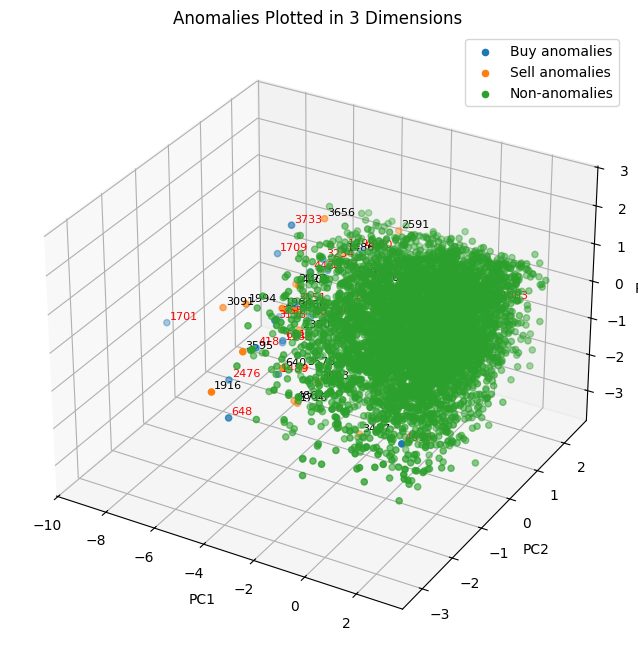

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 3D scatter for buy anomalies
ax.scatter(
    df_buy_anomalies["PC1"],
    df_buy_anomalies["PC2"],
    df_buy_anomalies["PC3"],
    label='Buy anomalies'
)

# 3D scatter for sell anomalies
ax.scatter(
    df_sell_anomalies["PC1"],
    df_sell_anomalies["PC2"],
    df_sell_anomalies["PC3"],
    label='Sell anomalies'
)

ax.scatter(
    df_non_anomalies_pca["PC1"],
    df_non_anomalies_pca["PC2"],
    df_non_anomalies_pca["PC3"],
    label='Non-anomalies'
)

# labels for buy anomalies on the dots
for i, idx in enumerate(df_buy_anomalies.index):
    ax.text(
        df_buy_anomalies["PC1"].iloc[i] + 0.05,
        df_buy_anomalies["PC2"].iloc[i] + 0.05,
        df_buy_anomalies["PC3"].iloc[i] + 0.05,
        str(idx),
        fontsize=8,
        color='red'
    )

# labels for sell anomalies
for i, idx in enumerate(df_sell_anomalies.index):
    ax.text(
        df_sell_anomalies["PC1"].iloc[i] + 0.05,
        df_sell_anomalies["PC2"].iloc[i] + 0.05,
        df_sell_anomalies["PC3"].iloc[i] + 0.05,
        str(idx),
        fontsize=8,
        color='black'
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Anomalies Plotted in 3 Dimensions")
ax.legend()

plt.show()

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

# buy anomalies
fig.add_trace(go.Scatter3d(
    x=df_buy_anomalies["PC1"],
    y=df_buy_anomalies["PC2"],
    z=df_buy_anomalies["PC3"],
    mode='markers+text',
    text=df_buy_anomalies['sorted_index'].tolist(),
    textposition="top center",
    name='Buy anomalies'
))

# sell anomalies
fig.add_trace(go.Scatter3d(
    x=df_sell_anomalies["PC1"],
    y=df_sell_anomalies["PC2"],
    z=df_sell_anomalies["PC3"],
    mode='markers+text',
    text=df_sell_anomalies['sorted_index'].tolist(),
    textposition="top center",
    name='Sell anomalies'
))

fig.add_trace(go.Scatter3d(
    x=df_non_anomalies_pca["PC1"],
    y=df_non_anomalies_pca["PC2"],
    z=df_non_anomalies_pca["PC3"],
    mode='markers+text',
    name='Non-anomalies',
    marker=dict(
        size=2,
        opacity=0.7
    )
))

fig.update_layout(
    scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3",
    ),
    title="Interactive 3D Anomalies from LSTM",
    height=800
)

fig.show()

In [ ]:
df_non_anomalies_pca

,PC1,PC2,PC3,PC4,PC5,sorted_index
1107,0.773718,-0.815370,0.315131,0.222019,1.888959,0
559,0.689984,-0.644825,-1.111661,0.166553,-1.569708,1
4848,-3.710558,1.156932,-0.383854,-1.318276,-0.345352,2
3257,-1.713394,1.428722,-0.305836,1.000828,0.390067,3
274,1.698913,0.461621,-2.391411,-0.547831,-0.030814,4
...,...,...,...,...,...,...
48,-1.989235,-0.708707,0.732157,-0.432480,-0.731621,4995
1140,-0.557100,0.056081,-1.034897,1.536482,-0.317203,4996
1500,0.418844,0.734747,-0.506791,1.467819,1.339141,4997
4827,1.837074,0.342931,-0.356031,1.371353,1.434682,4998


filtering out false positive anomalies - elliptical envelope

In [ ]:
from sklearn.covariance import EllipticEnvelope
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.stats import chi2
from scipy.linalg import cholesky

In [ ]:
# elliptical envelope - fit it
X_non_anoms = df_non_anomalies_pca[["PC1", "PC2", "PC3", "sorted_index"]]
envelope = EllipticEnvelope(contamination=0.05, random_state=42)
envelope.fit(X_non_anoms[["PC1", "PC2", "PC3"]])
X_anoms = pd.concat([df_buy_anomalies, df_sell_anomalies])[["PC1", "PC2", "PC3", "sorted_index"]]

# isolate false negatives
non_anomaly_preds = envelope.predict(X_non_anoms[["PC1", "PC2", "PC3"]])
false_negatives_sorted_index = X_non_anoms.loc[non_anomaly_preds == -1, "sorted_index"].tolist()

# isolate false positives
anomaly_preds = envelope.predict(X_anoms[["PC1", "PC2", "PC3"]])
false_positives_sorted_index = X_anoms.loc[anomaly_preds == 1, "sorted_index"].tolist()

print("False negatives (non-anomalies predicted as outliers):")
print(false_negatives_sorted_index)
print()
print("False positives (anomalies predicted as normal):")
print(false_positives_sorted_index)

False negatives (non-anomalies predicted as outliers):
[38, 95, 129, 130, 167, 178, 184, 222, 255, 266, 267, 274, 326, 357, 396, 406, 415, 430, 463, 492, 495, 508, 540, 565, 568, 580, 624, 634, 638, 667, 668, 672, 677, 691, 749, 756, 805, 855, 864, 872, 878, 902, 912, 923, 945, 946, 956, 959, 985, 1004, 1029, 1047, 1053, 1060, 1157, 1167, 1181, 1189, 1205, 1211, 1220, 1259, 1286, 1324, 1326, 1330, 1359, 1366, 1371, 1373, 1451, 1497, 1501, 1566, 1568, 1571, 1598, 1604, 1609, 1628, 1652, 1657, 1668, 1745, 1771, 1813, 1818, 1846, 1942, 1977, 1978, 1981, 2012, 2027, 2033, 2083, 2125, 2170, 2182, 2196, 2255, 2268, 2272, 2284, 2336, 2345, 2352, 2396, 2402, 2407, 2416, 2475, 2508, 2563, 2577, 2580, 2586, 2617, 2623, 2624, 2628, 2658, 2665, 2677, 2681, 2706, 2712, 2736, 2779, 2822, 2872, 2899, 2909, 2913, 2915, 2928, 2930, 2972, 3032, 3034, 3035, 3041, 3050, 3054, 3055, 3070, 3107, 3138, 3139, 3152, 3155, 3188, 3192, 3197, 3217, 3237, 3249, 3285, 3288, 3300, 3318, 3388, 3401, 3430, 3445, 3449,

In [ ]:
##
## this method is important because it predicts the ellipsoid envelope on the data
##

def get_ellipsoid_mesh(center, covariance, confidence_level=0.95, n_points=50):

    # radius
    degrees_of_freedom = 3
    scaling_factor = np.sqrt(chi2.isf(1 - confidence_level, degrees_of_freedom))

    # cholesky ellipse
    L = cholesky(covariance, lower=True)

    # points
    u = np.linspace(0, 2 * np.pi, n_points)
    v = np.linspace(0, np.pi, n_points)
    x_sphere = np.outer(np.cos(u), np.sin(v))
    y_sphere = np.outer(np.sin(u), np.sin(v))
    z_sphere = np.outer(np.ones(np.size(u)), np.cos(v))
    xyz_sphere = np.stack([x_sphere.flatten(), y_sphere.flatten(), z_sphere.flatten()])

    # numpy radius per region
    xyz_ellipsoid = scaling_factor * L @ xyz_sphere
    x_mesh = (xyz_ellipsoid[0, :] + center[0]).reshape(n_points, n_points)
    y_mesh = (xyz_ellipsoid[1, :] + center[1]).reshape(n_points, n_points)
    z_mesh = (xyz_ellipsoid[2, :] + center[2]).reshape(n_points, n_points)
    return x_mesh.flatten(), y_mesh.flatten(), z_mesh.flatten()

# from envelope fit, predict ellipsoid mesh
center = envelope.location_
covariance = envelope.covariance_
x_ellip, y_ellip, z_ellip = get_ellipsoid_mesh(center, covariance, confidence_level=0.95)

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()
fig = go.Figure()

# buy anomalies
fig.add_trace(go.Scatter3d(
    x=df_buy_anomalies["PC1"],
    y=df_buy_anomalies["PC2"],
    z=df_buy_anomalies["PC3"],
    mode='markers+text',
    text=df_buy_anomalies['sorted_index'].tolist(),
    textposition="top center",
    name='Buy anomalies'
))

# sell anomalies
fig.add_trace(go.Scatter3d(
    x=df_sell_anomalies["PC1"],
    y=df_sell_anomalies["PC2"],
    z=df_sell_anomalies["PC3"],
    mode='markers+text',
    text=df_sell_anomalies['sorted_index'].tolist(),
    textposition="top center",
    name='Sell anomalies'
))

fig.add_trace(go.Scatter3d(
    x=df_non_anomalies_pca["PC1"],
    y=df_non_anomalies_pca["PC2"],
    z=df_non_anomalies_pca["PC3"],
    mode='markers+text',
    name='Non-anomalies',
    marker=dict(
        size=2,
        opacity=0.7
    )
))

fig.update_layout(
    scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3",
    ),
    title="Interactive Anomalies from LSTM & Ellipsoid Envelope",
    height=800
)

# add ellipsoid envelope to visualization
fig.add_trace(go.Mesh3d(
    x=x_ellip,
    y=y_ellip,
    z=z_ellip,
    opacity=0.15,
    color='blue',
    name='95% Non-Anomaly Envelope',
    showlegend=True,
    alphahull=0
))

# false negatives in yellow
df_fn = df_non_anomalies_pca.loc[false_negatives_indices]
fig.add_trace(go.Scatter3d(
    x=df_fn["PC1"],
    y=df_fn["PC2"],
    z=df_fn["PC3"],
    mode='markers',
    marker=dict(size=5, color='orange', symbol='diamond'),
    name='Non-Anomalies OUTSIDE Envelope (FN)',
    text=[f"FN {i}" for i in df_fn.index]
))

# false positives (not important in main argument)
df_fp = X_anoms.loc[false_positives_indices].reset_index()
fig.add_trace(go.Scatter3d(
    x=df_fp["PC1"],
    y=df_fp["PC2"],
    z=df_fp["PC3"],
    mode='markers',
    marker=dict(size=5, color='purple', symbol='square'),
    name='Anomalies INSIDE Envelope (FP)',
    text=[f"FP {i}" for i in df_fp['index']]
))

fig.update_layout(
    scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3",
    ),
    title="Interactive Anomalies and Ellipsoid Envelope for FP and FN identification",
    height=800
)

fig.show()

In [ ]:
df_fn

,PC1,PC2,PC3,PC4,PC5
2522,-2.012851,-2.659088,-0.861231,-1.367454,-0.962669
236,-2.526168,-2.329310,1.319018,0.268609,0.605191
382,-4.925234,-1.326036,-0.727193,-0.778503,0.897380
3685,-2.451824,0.368323,-2.216788,-0.316404,-1.362595
3960,-3.957518,0.045620,1.095831,0.623390,-1.141784
...,...,...,...,...,...
4288,-2.631564,-0.676557,2.131350,0.802169,-1.473010
617,1.042069,-1.777829,-2.449093,0.900754,-1.818456
2921,-5.274071,-0.784631,-1.102799,-0.575586,-0.028773
4933,0.115701,-2.699813,-0.503454,-0.159227,1.097675


mann whitney test of these ^^ anomalies

In [ ]:
# df_anomalies_scientific_data has data for these 7 numerical features
# df is the originals

# removed the 2 false positives
fixed_anoms = [46, 86, 91, 173, 286, 559, 586, 636, 704, 928, 987, 1356, 1523, 1675, 1831, 1849, 1948, 1985, 2166, 2183, 2186, 2207, 2311, 2547, 2690, 2873, 2961, 2976,
                       3048, 3247, 3634, 3712, 4175, 4215, 4355, 4371, 4385, 4466, 4528, 4697, 4772, 4898]



rows_to_keep_mask = ~df.index.isin(fixed_anoms)

df_excluded_anoms = df.loc[rows_to_keep_mask]

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_anomalies_scientific_data2 = df.iloc[fixed_anoms]

columns_to_test = [
    'Energy_Demand_MWh', 'Emission_Produced_tCO2', 'Emission_Allowance_tCO2',
    'Carbon_Price_USD_per_t', 'Credits_Traded_tCO2', 'Compliance_Cost_USD',
    'Carbon_Cost_Savings_USD'
]
alpha = 0.05
test_results = []

for col in columns_to_test:
    try:
        anomaly_values = df_anomalies_scientific_data2[col].dropna()
        non_anomaly_values = df_excluded_anoms[col].dropna()
    except KeyError:
        test_results.append({
            'Metric': col, 'U_Statistic': np.nan, 'P_Value': np.nan,
            'N_Anomalies': 0, 'N_NonAnomalies': 0, 'Conclusion': 'Column Not Found'
        })
        continue

    # this is check for sufficient data
    if len(anomaly_values) < 5 or len(non_anomaly_values) < 5:
        test_results.append({
            'Metric': col, 'U_Statistic': np.nan, 'P_Value': np.nan,
            'N_Anomalies': len(anomaly_values), 'N_NonAnomalies': len(non_anomaly_values),
            'Conclusion': 'Insufficient Data (N < 5)'
        })
        continue

    # mann whitney
    u_statistic, p_value = mannwhitneyu(
        x=anomaly_values,
        y=non_anomaly_values,
        alternative='two-sided'
    )


    if p_value < alpha:
        conclusion = "Significantly Different (Reject H0)"
    else:
        conclusion = "No Significant Difference (Fail to Reject H0)"


    test_results.append({
        'Metric': col,
        'U_Statistic': round(u_statistic, 2),
        'P_Value': round(p_value, 4),
        'N_Anomalies': len(anomaly_values),
        'N_NonAnomalies': len(non_anomaly_values),
        'Conclusion': conclusion
    })

results_df = pd.DataFrame(test_results)
print("--- Mann-Whitney U Test Summary Table ---")

# visualise this
df_anomalies_scientific_data2['Group'] = 'Anomaly'
df_excluded_anoms['Group'] = 'Non-Anomaly'

df_combined = pd.concat([df_anomalies_scientific_data2, df_excluded_anoms], ignore_index=True)

df_combined_melt = pd.melt(
    df_combined,
    id_vars=['Group'],
    value_vars=columns_to_test,
    var_name='Metric',
    value_name='Value'
)

results_df

--- Mann-Whitney U Test Summary Table ---


/tmp/ipython-input-3055842253.py:64: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-3055842253.py:65: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Metric,U_Statistic,P_Value,N_Anomalies,N_NonAnomalies,Conclusion
0,Energy_Demand_MWh,13533.5,0.0000,42,4958,Significantly Different (Reject H0)
1,Emission_Produced_tCO2,8906.0,0.0000,42,4958,Significantly Different (Reject H0)
2,Emission_Allowance_tCO2,7669.0,0.0000,42,4958,Significantly Different (Reject H0)
3,Carbon_Price_USD_per_t,113353.5,0.3215,42,4958,No Significant Difference (Fail to Reject H0)
4,Credits_Traded_tCO2,69953.0,0.0002,42,4958,Significantly Different (Reject H0)
5,Compliance_Cost_USD,94506.0,0.3022,42,4958,No Significant Difference (Fail to Reject H0)
6,Carbon_Cost_Savings_USD,107291.0,0.7334,42,4958,No Significant Difference (Fail to Reject H0)


/tmp/ipython-input-4283781203.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-4283781203.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-4283781203.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-4283781203.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-4283781203.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated a

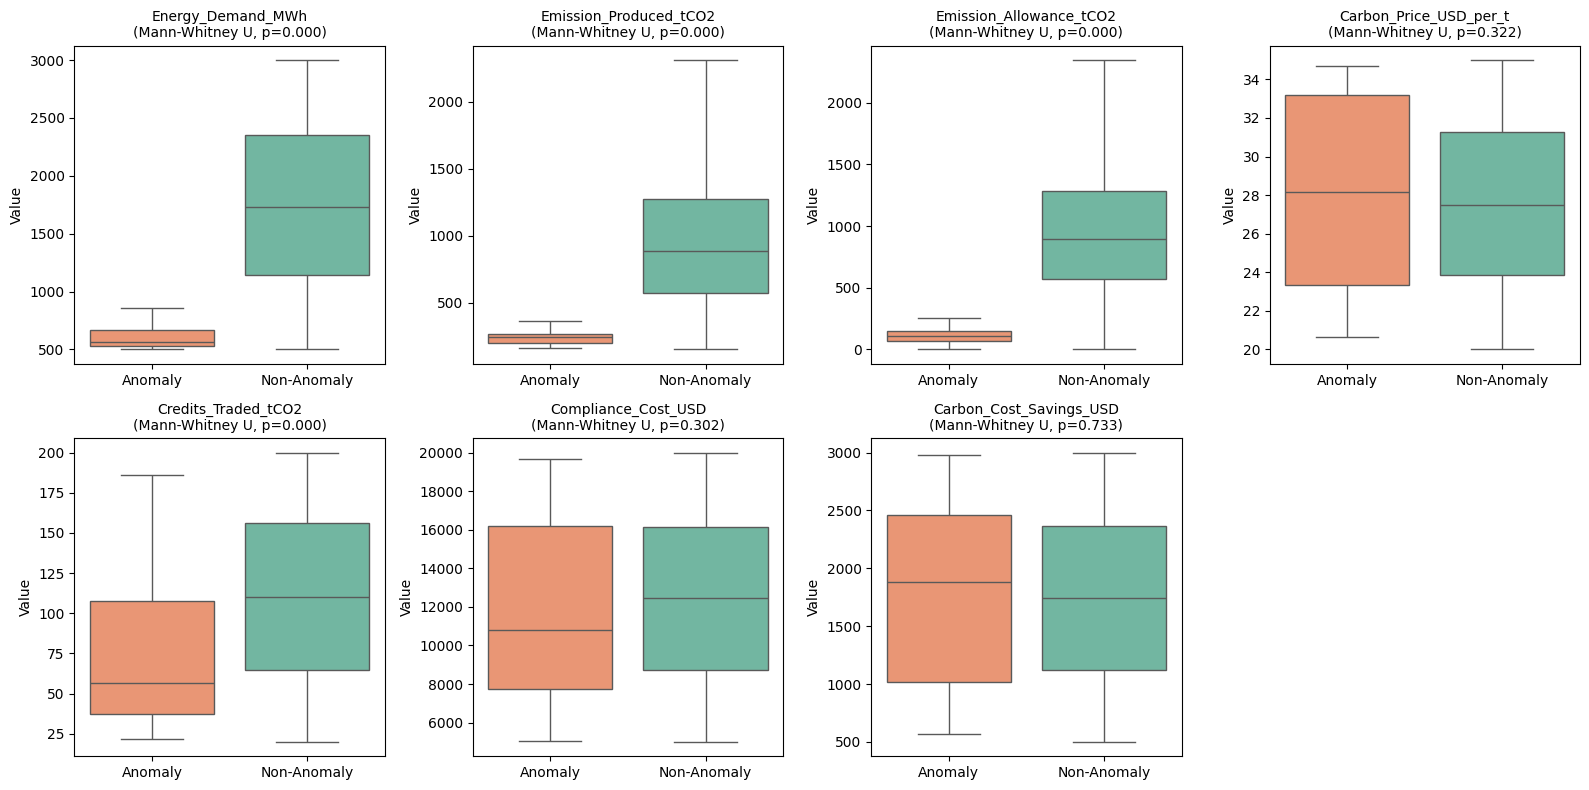

In [ ]:
# holy data visualizations for the buy subset

num_plots = len(columns_to_test)
rows = int(np.ceil(num_plots / 4))
cols = 4 if num_plots > 4 else num_plots
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten()

# p-values from the results table
for i, col in enumerate(columns_to_test):
    plot_data = df_combined_melt[df_combined_melt['Metric'] == col]

    summary_row = results_df[results_df['Metric'] == col].iloc[0]
    p_value = summary_row['P_Value']

    sns.boxplot(
        x='Group',
        y='Value',
        data=plot_data,
        ax=axes[i],
        palette={'Anomaly': sns.color_palette("Set2")[1], 'Non-Anomaly': sns.color_palette("Set2")[0]},
        showfliers=False
    )


    if not pd.isna(p_value):
        axes[i].set_title(f"{col}\n(Mann-Whitney U, p={p_value:.3f})", fontsize=10)

    axes[i].set_xlabel("")
    axes[i].set_ylabel("Value")

for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

selling subset

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# df_anomalies_scientific_data has data for these 7 numerical features
# df is the originals

# removed the 2 false positives
sell_anoms = [86, 91, 173, 559, 586, 636, 704, 928, 1356, 1948, 2186, 2311, 2873, 2961, 3247, 3712, 4215, 4371, 4385, 4697, 4772]

rows_to_keep_mask = ~df.index.isin(sell_anoms)

df_excluded_anoms = df.loc[rows_to_keep_mask]

In [ ]:
# same as above for the sell subset

df_anomalies_scientific_data2 = df.iloc[sell_anoms]

columns_to_test = [
    'Energy_Demand_MWh', 'Emission_Produced_tCO2', 'Emission_Allowance_tCO2',
    'Carbon_Price_USD_per_t', 'Credits_Traded_tCO2', 'Compliance_Cost_USD',
    'Carbon_Cost_Savings_USD'
]
alpha = 0.05
test_results = []

for col in columns_to_test:
    try:
        anomaly_values = df_anomalies_scientific_data2[col].dropna()
        non_anomaly_values = df_excluded_anoms[col].dropna()
    except KeyError:
        test_results.append({
            'Metric': col, 'U_Statistic': np.nan, 'P_Value': np.nan,
            'N_Anomalies': 0, 'N_NonAnomalies': 0, 'Conclusion': 'Column Not Found'
        })
        continue

    # this is check for sufficient data
    if len(anomaly_values) < 5 or len(non_anomaly_values) < 5:
        test_results.append({
            'Metric': col, 'U_Statistic': np.nan, 'P_Value': np.nan,
            'N_Anomalies': len(anomaly_values), 'N_NonAnomalies': len(non_anomaly_values),
            'Conclusion': 'Insufficient Data (N < 5)'
        })
        continue

    # mann whitney
    u_statistic, p_value = mannwhitneyu(
        x=anomaly_values,
        y=non_anomaly_values,
        alternative='two-sided'
    )


    if p_value < alpha:
        conclusion = "Significantly Different (Reject H0)"
    else:
        conclusion = "No Significant Difference (Fail to Reject H0)"


    test_results.append({
        'Metric': col,
        'U_Statistic': round(u_statistic, 2),
        'P_Value': round(p_value, 4),
        'N_Anomalies': len(anomaly_values),
        'N_NonAnomalies': len(non_anomaly_values),
        'Conclusion': conclusion
    })

results_df = pd.DataFrame(test_results)
print("--- Mann-Whitney U Test Summary Table ---")

# visualise
df_anomalies_scientific_data2['Group'] = 'Anomaly'
df_excluded_anoms['Group'] = 'Non-Anomaly'

df_combined = pd.concat([df_anomalies_scientific_data2, df_excluded_anoms], ignore_index=True)

df_combined_melt = pd.melt(
    df_combined,
    id_vars=['Group'],
    value_vars=columns_to_test,
    var_name='Metric',
    value_name='Value'
)

results_df

--- Mann-Whitney U Test Summary Table ---


/tmp/ipython-input-2949652252.py:64: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-2949652252.py:65: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Metric,U_Statistic,P_Value,N_Anomalies,N_NonAnomalies,Conclusion
0,Energy_Demand_MWh,5221.0,0.0000,21,4979,Significantly Different (Reject H0)
1,Emission_Produced_tCO2,2555.5,0.0000,21,4979,Significantly Different (Reject H0)
2,Emission_Allowance_tCO2,1941.5,0.0000,21,4979,Significantly Different (Reject H0)
3,Carbon_Price_USD_per_t,66881.0,0.0270,21,4979,Significantly Different (Reject H0)
4,Credits_Traded_tCO2,31263.0,0.0015,21,4979,Significantly Different (Reject H0)
5,Compliance_Cost_USD,47066.5,0.4297,21,4979,No Significant Difference (Fail to Reject H0)
6,Carbon_Cost_Savings_USD,59461.5,0.2766,21,4979,No Significant Difference (Fail to Reject H0)


/tmp/ipython-input-4283781203.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-4283781203.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-4283781203.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-4283781203.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-4283781203.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated a

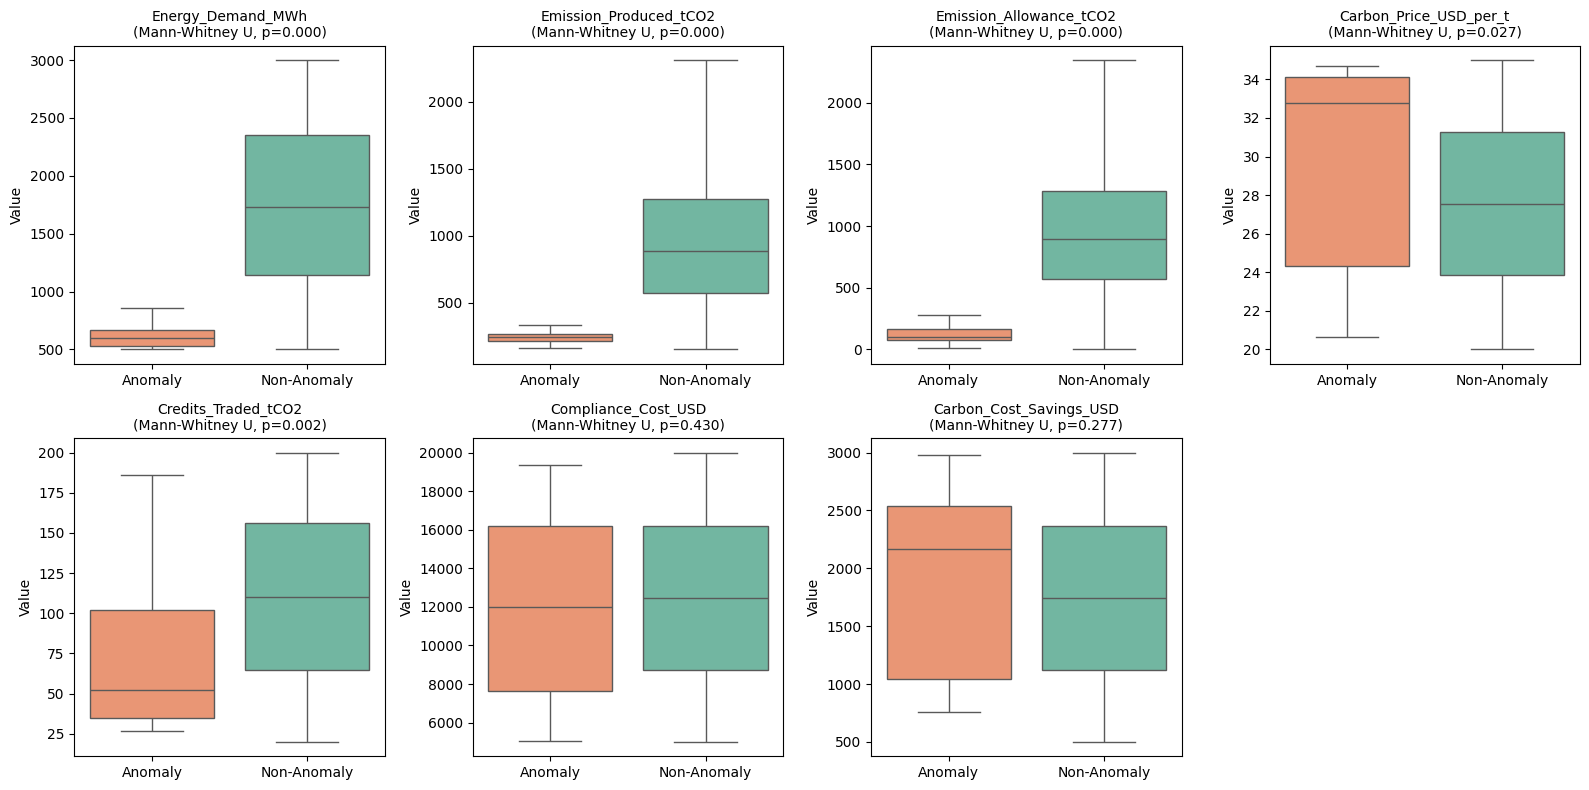

In [ ]:

num_plots = len(columns_to_test)
rows = int(np.ceil(num_plots / 4))
cols = 4 if num_plots > 4 else num_plots
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten()

# p-values from the results table
for i, col in enumerate(columns_to_test):
    plot_data = df_combined_melt[df_combined_melt['Metric'] == col]

    summary_row = results_df[results_df['Metric'] == col].iloc[0]
    p_value = summary_row['P_Value']

    sns.boxplot(
        x='Group',
        y='Value',
        data=plot_data,
        ax=axes[i],
        palette={'Anomaly': sns.color_palette("Set2")[1], 'Non-Anomaly': sns.color_palette("Set2")[0]},
        showfliers=False
    )


    if not pd.isna(p_value):
        axes[i].set_title(f"{col}\n(Mann-Whitney U, p={p_value:.3f})", fontsize=10)

    axes[i].set_xlabel("")
    axes[i].set_ylabel("Value")

for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

buy subset with FP removed

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# df_anomalies_scientific_data has data for these 7 numerical features
# df is the originals

# removed the 2 false positives
buy_anoms = [46, 286, 987, 1849, 1985, 2166, 2183, 2207, 2547, 2976, 3048, 3634, 4174, 4175, 4355, 4466, 4528, 4898]
# 1523 1675 1831 2690 outliers

rows_to_keep_mask = ~df.index.isin(buy_anoms)

df_excluded_anoms = df.loc[rows_to_keep_mask]

In [ ]:
df_anomalies_scientific_data2 = df.iloc[buy_anoms]

columns_to_test = [
    'Energy_Demand_MWh', 'Emission_Produced_tCO2', 'Emission_Allowance_tCO2',
    'Carbon_Price_USD_per_t', 'Credits_Traded_tCO2', 'Compliance_Cost_USD',
    'Carbon_Cost_Savings_USD'
]
alpha = 0.05
test_results = []

for col in columns_to_test:
    try:
        anomaly_values = df_anomalies_scientific_data2[col].dropna()
        non_anomaly_values = df_excluded_anoms[col].dropna()
    except KeyError:
        test_results.append({
            'Metric': col, 'U_Statistic': np.nan, 'P_Value': np.nan,
            'N_Anomalies': 0, 'N_NonAnomalies': 0, 'Conclusion': 'Column Not Found'
        })
        continue

    # this is check for sufficient data
    if len(anomaly_values) < 5 or len(non_anomaly_values) < 5:
        test_results.append({
            'Metric': col, 'U_Statistic': np.nan, 'P_Value': np.nan,
            'N_Anomalies': len(anomaly_values), 'N_NonAnomalies': len(non_anomaly_values),
            'Conclusion': 'Insufficient Data (N < 5)'
        })
        continue

    # mann whitney
    u_statistic, p_value = mannwhitneyu(
        x=anomaly_values,
        y=non_anomaly_values,
        alternative='two-sided'
    )


    if p_value < alpha:
        conclusion = "Significantly Different (Reject H0)"
    else:
        conclusion = "No Significant Difference (Fail to Reject H0)"


    test_results.append({
        'Metric': col,
        'U_Statistic': round(u_statistic, 2),
        'P_Value': round(p_value, 4),
        'N_Anomalies': len(anomaly_values),
        'N_NonAnomalies': len(non_anomaly_values),
        'Conclusion': conclusion
    })

results_df = pd.DataFrame(test_results)
print("--- Mann-Whitney U Test Summary Table ---")

# visualise this
df_anomalies_scientific_data2['Group'] = 'Anomaly'
df_excluded_anoms['Group'] = 'Non-Anomaly'

df_combined = pd.concat([df_anomalies_scientific_data2, df_excluded_anoms], ignore_index=True)

df_combined_melt = pd.melt(
    df_combined,
    id_vars=['Group'],
    value_vars=columns_to_test,
    var_name='Metric',
    value_name='Value'
)

results_df

--- Mann-Whitney U Test Summary Table ---


/tmp/ipython-input-2392803976.py:64: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-2392803976.py:65: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Metric,U_Statistic,P_Value,N_Anomalies,N_NonAnomalies,Conclusion
0,Energy_Demand_MWh,12637.0,0.0000,18,4982,Significantly Different (Reject H0)
1,Emission_Produced_tCO2,10215.0,0.0000,18,4982,Significantly Different (Reject H0)
2,Emission_Allowance_tCO2,9586.0,0.0000,18,4982,Significantly Different (Reject H0)
3,Carbon_Price_USD_per_t,32804.0,0.0490,18,4982,Significantly Different (Reject H0)
4,Credits_Traded_tCO2,36706.0,0.1835,18,4982,No Significant Difference (Fail to Reject H0)
5,Compliance_Cost_USD,39060.0,0.3446,18,4982,No Significant Difference (Fail to Reject H0)
6,Carbon_Cost_Savings_USD,41993.0,0.6417,18,4982,No Significant Difference (Fail to Reject H0)


/tmp/ipython-input-4283781203.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-4283781203.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-4283781203.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-4283781203.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-4283781203.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated a

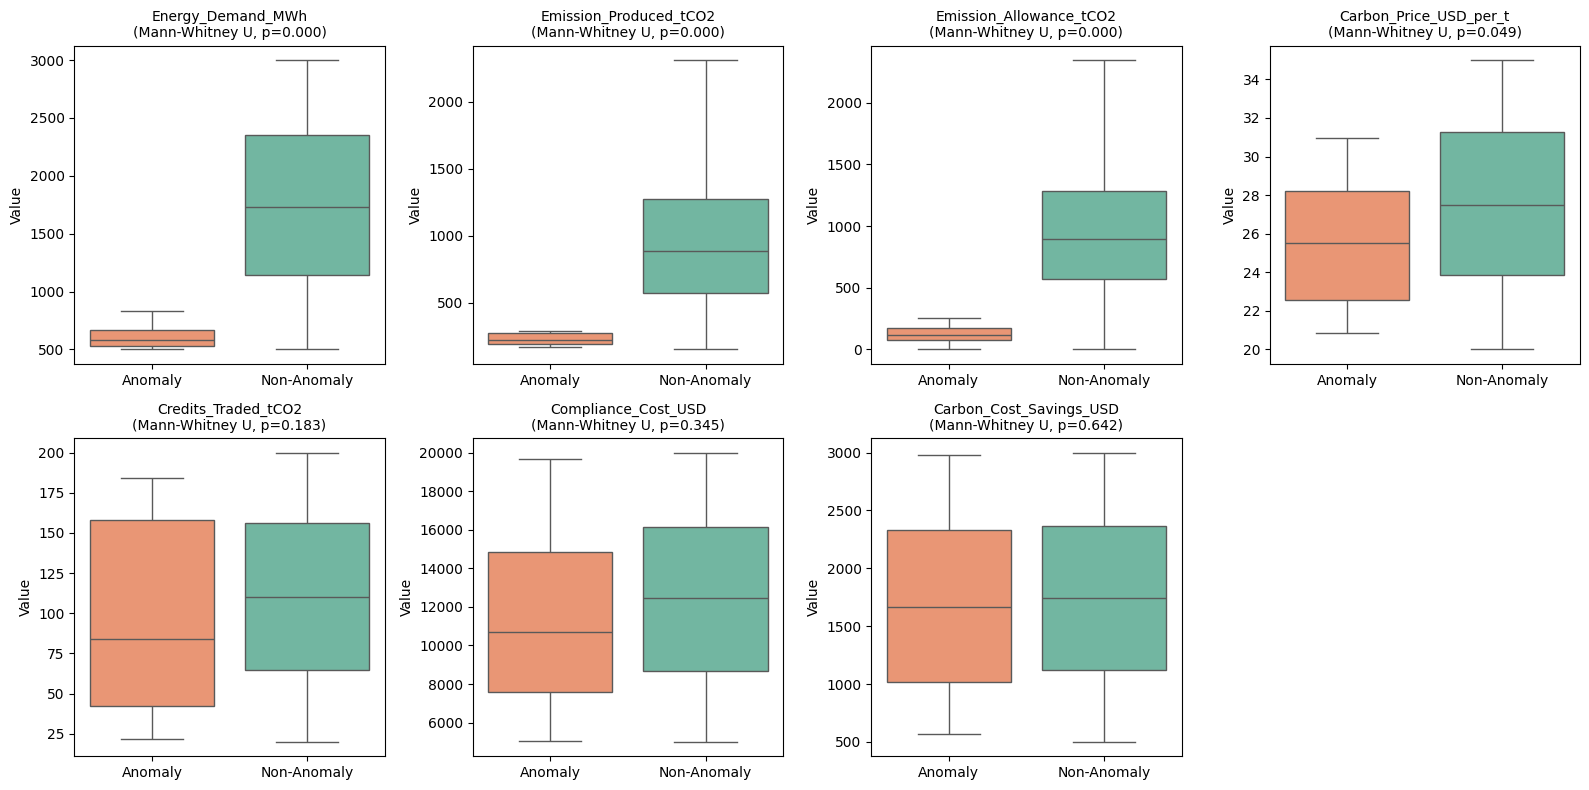

In [ ]:

num_plots = len(columns_to_test)
rows = int(np.ceil(num_plots / 4))
cols = 4 if num_plots > 4 else num_plots
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten()

# p-values from the results table
for i, col in enumerate(columns_to_test):
    plot_data = df_combined_melt[df_combined_melt['Metric'] == col]

    summary_row = results_df[results_df['Metric'] == col].iloc[0]
    p_value = summary_row['P_Value']

    sns.boxplot(
        x='Group',
        y='Value',
        data=plot_data,
        ax=axes[i],
        palette={'Anomaly': sns.color_palette("Set2")[1], 'Non-Anomaly': sns.color_palette("Set2")[0]},
        showfliers=False
    )


    if not pd.isna(p_value):
        axes[i].set_title(f"{col}\n(Mann-Whitney U, p={p_value:.3f})", fontsize=10)

    axes[i].set_xlabel("")
    axes[i].set_ylabel("Value")

for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

now doing violin plots

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

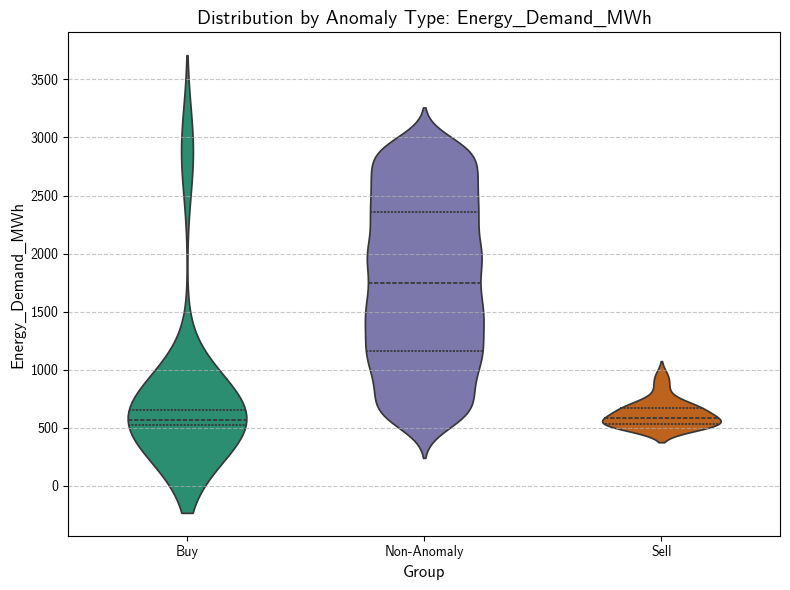

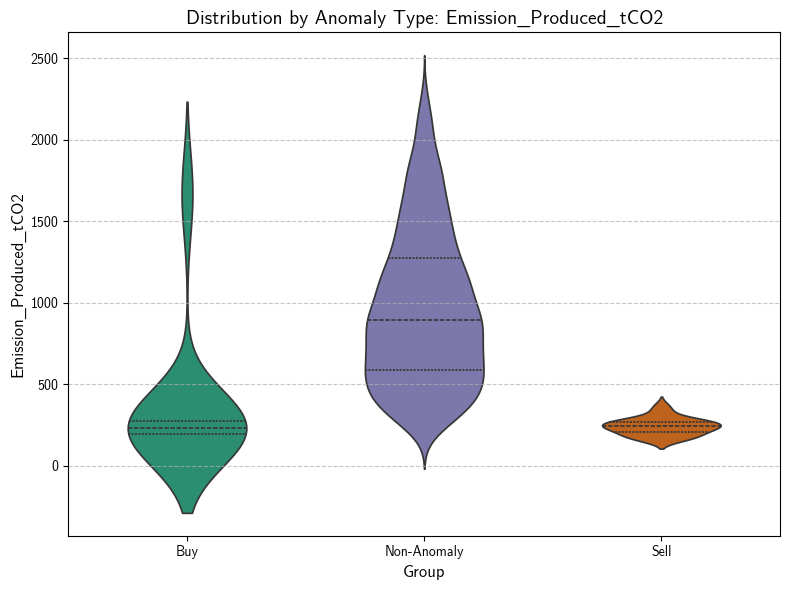

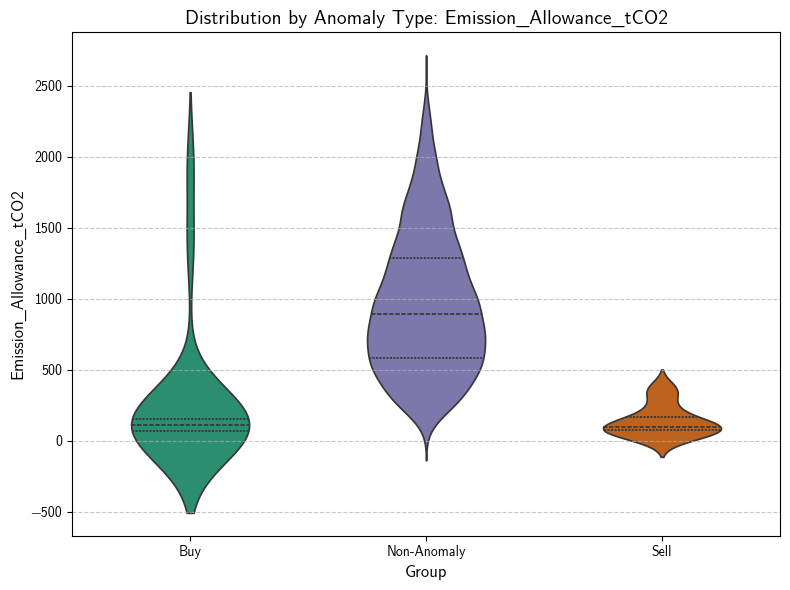

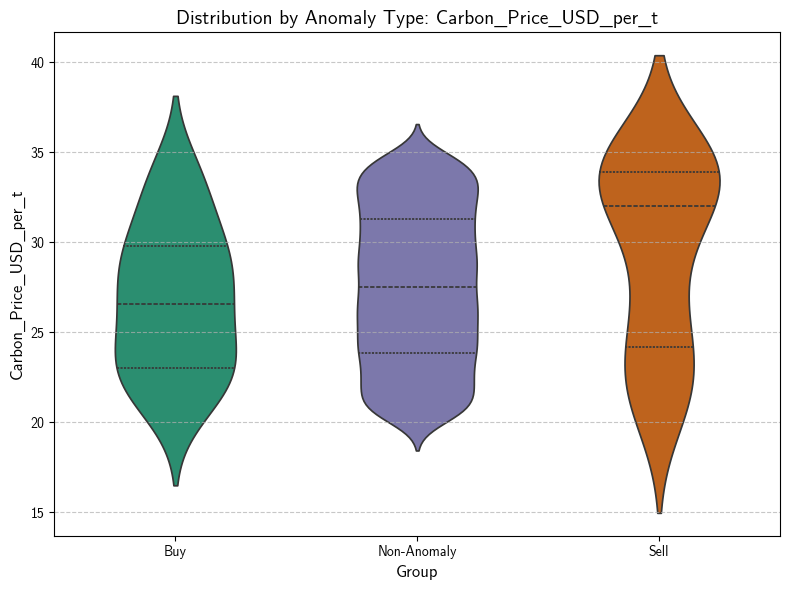

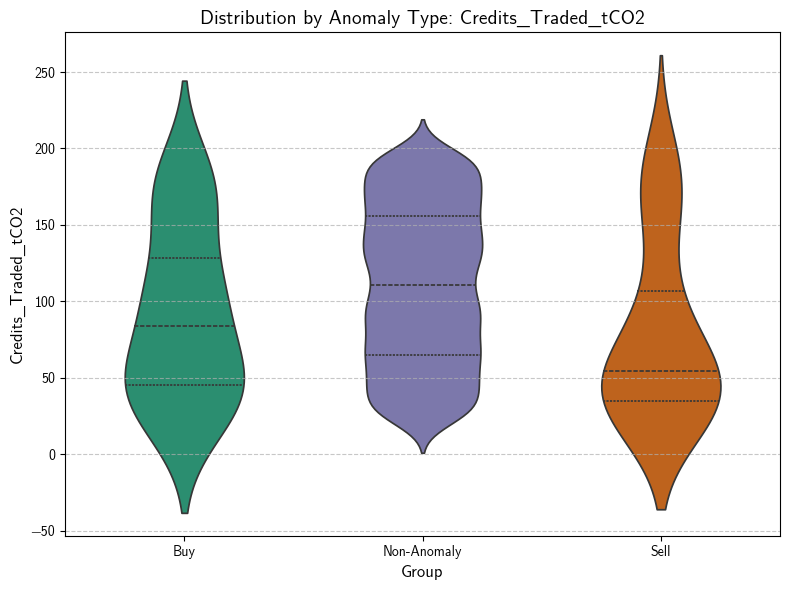

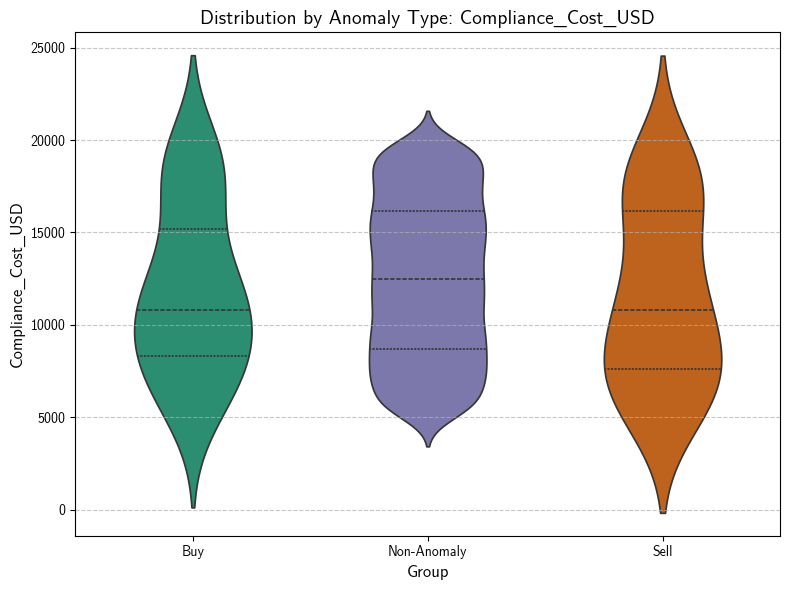

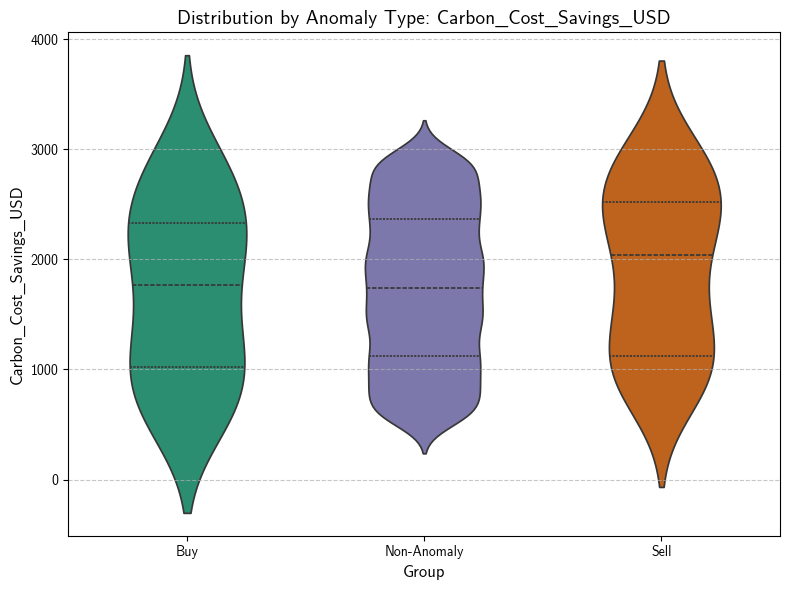

In [ ]:
# font
plt.rcParams["text.usetex"] = False
font_path = "/content/lmsans10-regular.otf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "Latin Modern Sans"

# subsets
buy_labels = df.iloc[buy].index
sell_labels = df.iloc[sell].index

df['Anomaly_Type'] = 'Non-Anomaly'
df.loc[buy_labels, 'Anomaly_Type'] = 'Buy'
df.loc[sell_labels, 'Anomaly_Type'] = 'Sell'
plot_order = ["Buy", "Non-Anomaly", "Sell"]

anomaly_palette = {
    'Buy': '#1b9e77',
    'Non-Anomaly': '#7570b3',
    'Sell': '#d95f02'
}

# violin plot for each relevant time series feature
for feature in relevant_cols:
    plt.figure(figsize=(8, 6))

    sns.violinplot(
        x='Anomaly_Type',
        y=feature,
        data=df,
        hue='Anomaly_Type',
        palette=anomaly_palette,
        inner='quartile',
        legend=False,
        order=plot_order,
        width=0.5
    )

    plt.title(f'Distribution by Anomaly Type: {feature}', fontsize=14)
    plt.xlabel('Group', fontsize=12)
    plt.ylabel(feature, fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    plt.show()